## Keyword Extraction System — Comparison Analysis

This notebook provides a full evaluation and comparison of three keyword extraction methods:
- **Baseline**: TF-IDF
- **Advanced**: Word2Vec (centroid similarity)
- **Hybrid**: TF-IDF weighted Word2Vec

In [1]:
import pandas as pd
import ast
import json

papers = pd.read_csv('../data/papers_preprocessed.csv')
papers['lemmatized_tokens'] = papers['lemmatized_tokens'].apply(ast.literal_eval)

papers_original = pd.read_csv('../data/papers.csv')

papers['original_text'] = papers_original['full_text']
papers['title'] = papers_original['title']

with open('../results/tfidf_results.json', 'r') as f:
    papers['tfidf_keywords'] = json.load(f)

with open('../results/w2v_results.json', 'r') as f:
    papers['w2v_keywords'] = json.load(f)

with open('../results/hybrid_w2v_results.json', 'r') as f:
    papers['hybrid_keywords'] = json.load(f)

print(f"Loaded {len(papers)} papers with 3 keyword sets.")
papers[['tfidf_keywords', 'w2v_keywords', 'hybrid_keywords']].head(3)

Loaded 9607 papers with 3 keyword sets.


,tfidf_keywords,w2v_keywords,hybrid_keywords
0,"[state, synaptic, neuron, synaptic_weight, ari...","[noise_immunity, receiv_ing, silicon_wafer, sa...","[receiv_ing, noise_immunity, excita_tion, satu..."
1,"[environment, neuron, connectivity, entropy, bit]","[infor_mally, hence, there, particular, rather]","[neuron, environment, synaps, vironment, rather]"
2,"[neuron, hopfield, capacity, relation, converg...","[tje, particular, nlf, there, since]","[neuron, nlf, defme, tje, rela_tions]"


### Main Idea Extraction (Extractive Summarization)

- Identify the main idea of each paper without reading the full text.
- Score each sentence by how many TF-IDF keywords it contains. Return the top 3 sentences.

In [2]:
import re

def get_top_sentences(text, tfidf_keywords, top_n=3):
    if not isinstance(text, str):
        return ""
    
    text = re.sub(r'\(cid:\d+\)', '', text)
    text = re.sub(r'\s+', ' ', text)
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())

    sentences = [
        s for s in sentences
        if len(s.split()) > 8           
        and len(s.split()) < 60         
        and s[0].isupper()              
        and not re.search(r'\d{4,}', s) 
        and not s.startswith('Figure')
        and not s.startswith('Table')
    ]

    valid_sentences = []
    for s in sentences:
        words = s.split()
        if 12 < len(words) < 45:
            num_count = sum(1 for char in s if char.isdigit())
            if num_count / len(s) < 0.1: 
                valid_sentences.append(s)

    if not valid_sentences:
        return "Could not extract a readable summary."
    
    kw_set = set(tfidf_keywords)
    scored = []
    for i, s in enumerate(valid_sentences):
        score = sum(1 for w in s.lower().split() if w in kw_set)
        if i == 0: score += 2 
        scored.append((s, score, i)) 

    top_scored = sorted(scored, key=lambda x: x[1], reverse=True)[:top_n]
    
    final_sentences = sorted(top_scored, key=lambda x: x[2])

    return ' '.join([s[0] for s in final_sentences])


papers['main_idea'] = papers.apply(
    lambda row: get_top_sentences(
        row.get('original_text', ''),
        row['tfidf_keywords'],
        top_n=3
    ),
    axis=1
)

print("Main idea extraction complete.")

Main idea extraction complete.


In [3]:
for idx in [0, 100, 500]:
    row = papers.iloc[idx]
    print(f"=== Paper {idx} ===")
    print(f"Keywords  : {row['tfidf_keywords']}")
    print(f"Main Idea : {row['main_idea']}")
    print()

=== Paper 0 ===
Keywords  : ['state', 'synaptic', 'neuron', 'synaptic_weight', 'arithmetic']
Main Idea : The state signals are con nected to a n - bit horizontal bus running through the synaptic array, with a con nection to each synaptic operator in every column. The synaptic function is therefore to multiply the signalling neuron state, Vj , by the synaptic weight, Tij , and to add this product to the running total. Each synaptic operator includes an 8 bit shift register memory block holding the synaptic weight, Til' A 3 bit bus for the 5 neural states runs horizontally above each synaptic row.

=== Paper 100 ===
Keywords  : ['joint_angle', 'configuration', 'arm', 'rein', 'unit']
Main Idea : Ackley Bell Communications Research Cognitive Science Research Group ABSTRACT ALVIS is a reinforcement-based connectionist architecture that learns associative maps in continuous multidimensional environ ments. The don't-be unit with the largest activation value (which is a function of both the di

### Highlight Key Information Automatically

Keywords from both TF-IDF and Word2Vec are highlighted inside the extracted main idea sentences.

In [4]:
from IPython.display import HTML, display


def highlight_keywords(text, keywords):
    # TF-IDF keywords → yellow
    # Word2Vec keywords → light blue (if not already highlighted)
    if not isinstance(text, str) or not text.strip():
        return "<i>No summary available.</i>"
    
    keywords = sorted(list(set(keywords)), key=len, reverse=True)
    
    for kw in keywords:
        kw_pattern = re.escape(kw).replace(r'\_', r'[\s\_]')
        
        pattern = re.compile(kw_pattern, re.IGNORECASE)
        
        text = pattern.sub(
            f'<mark style="background-color: #FFFF00; font-weight: bold;">\g<0></mark>',
            text
        )
    return text


for idx in [0, 100, 500]:
    row = papers.iloc[idx]
    summary  = row['main_idea']
    keywords = list(set(row['tfidf_keywords'] + row['w2v_keywords'] + row['hybrid_keywords']))
    
    highlighted = highlight_keywords(summary, keywords)
    
    title = row.get('title', f'Paper {idx}')
    display(HTML(f"""
        <div style="border:1px solid #ddd; padding:12px; margin:8px 0; border-radius:6px;">
            <b>Paper {idx}: {title}</b><br><br>
            <b>Keywords:</b> {', '.join(row['tfidf_keywords'])}<br><br>
            <b>Main Idea:</b><br>{highlighted}
        </div>
    """))


#### Side-by-Side Keyword Comparison

In [5]:
print(f"{'Paper':<8} {'TF-IDF':<40} {'Word2Vec':<40} {'Hybrid'}")
print("-" * 130)
for i in range(10):
    tfidf  = str(papers['tfidf_keywords'].iloc[i])
    w2v    = str(papers['w2v_keywords'].iloc[i])
    hybrid = str(papers['hybrid_keywords'].iloc[i])
    print(f"{i:<8} {tfidf:<40} {w2v:<40} {hybrid}")

Paper    TF-IDF                                   Word2Vec                                 Hybrid
----------------------------------------------------------------------------------------------------------------------------------
0        ['state', 'synaptic', 'neuron', 'synaptic_weight', 'arithmetic'] ['noise_immunity', 'receiv_ing', 'silicon_wafer', 'satura_tion', 'aspire'] ['receiv_ing', 'noise_immunity', 'excita_tion', 'satura_tion', 'interconnected_neuron']
1        ['environment', 'neuron', 'connectivity', 'entropy', 'bit'] ['infor_mally', 'hence', 'there', 'particular', 'rather'] ['neuron', 'environment', 'synaps', 'vironment', 'rather']
2        ['neuron', 'hopfield', 'capacity', 'relation', 'convergence'] ['tje', 'particular', 'nlf', 'there', 'since'] ['neuron', 'nlf', 'defme', 'tje', 'rela_tions']
3        ['bump', 'neural_net', 'surface', 'neuron', 'input'] ['schemat', 'tje', 'rather', 'bumps', 'tanhs'] ['bumps', 'schemat', 'tanhs', 'tje', 'inputs']
4        ['cell', 'node', 

#### Top Keywords Visualization — All Three Methods

C:\Users\Reem\AppData\Local\Temp\ipykernel_14196\402138311.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Keyword', data=top_tfidf,  palette='Blues_d',  ax=axes[0])
C:\Users\Reem\AppData\Local\Temp\ipykernel_14196\402138311.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Keyword', data=top_w2v,    palette='Greens_d', ax=axes[1])
C:\Users\Reem\AppData\Local\Temp\ipykernel_14196\402138311.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Keyword', data=top_hybrid, palette='Oranges_d', ax=

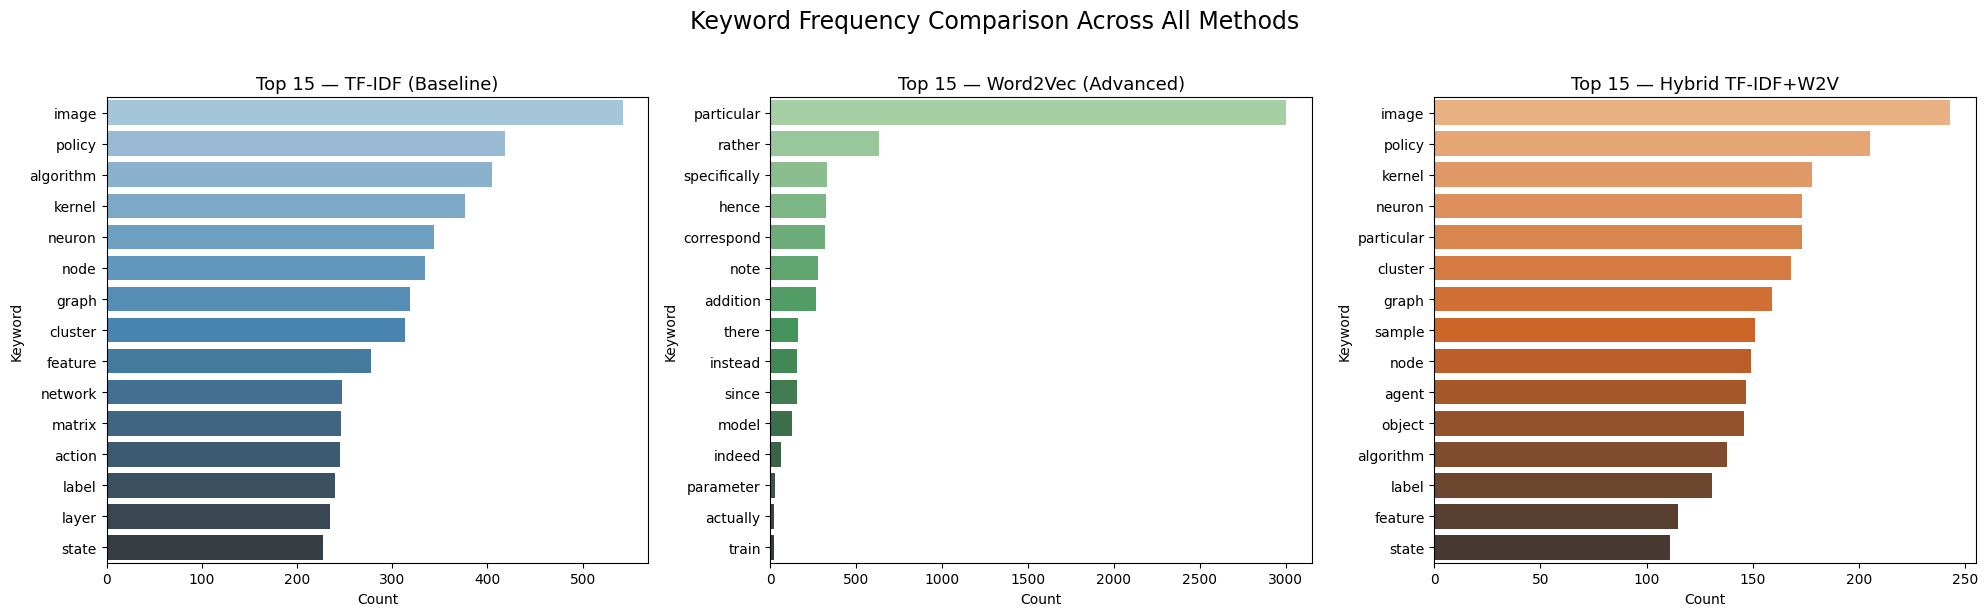

In [14]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)

all_tfidf  = [kw for kws in papers['tfidf_keywords']   for kw in kws]
all_w2v    = [kw for kws in papers['w2v_keywords']     for kw in kws]
all_hybrid = [kw for kws in papers['hybrid_keywords']  for kw in kws]

top_tfidf  = pd.DataFrame(Counter(all_tfidf).most_common(15),  columns=['Keyword', 'Count'])
top_w2v    = pd.DataFrame(Counter(all_w2v).most_common(15),    columns=['Keyword', 'Count'])
top_hybrid = pd.DataFrame(Counter(all_hybrid).most_common(15), columns=['Keyword', 'Count'])

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(x='Count', y='Keyword', data=top_tfidf,  palette='Blues_d',  ax=axes[0])
axes[0].set_title('Top 15 — TF-IDF (Baseline)', fontsize=13)

sns.barplot(x='Count', y='Keyword', data=top_w2v,    palette='Greens_d', ax=axes[1])
axes[1].set_title('Top 15 — Word2Vec (Advanced)', fontsize=13)

sns.barplot(x='Count', y='Keyword', data=top_hybrid, palette='Oranges_d', ax=axes[2])
axes[2].set_title('Top 15 — Hybrid TF-IDF+W2V', fontsize=13)

plt.suptitle('Keyword Frequency Comparison Across All Methods', fontsize=17, y=1.02)
plt.tight_layout()
plt.show()


#### Jaccard Overlap Between Methods

Jaccard overlap measures how much two keyword sets agree:
- **0.0** = completely different keywords
- **1.0** = identical keywords

In [7]:
def jaccard(list1, list2):
    s1, s2 = set(list1), set(list2)
    if not s1 or not s2:
        return 0.0
    return len(s1 & s2) / len(s1 | s2)


papers['overlap_tfidf_w2v']    = papers.apply(lambda r: jaccard(r['tfidf_keywords'],  r['w2v_keywords']),    axis=1)
papers['overlap_tfidf_hybrid'] = papers.apply(lambda r: jaccard(r['tfidf_keywords'],  r['hybrid_keywords']), axis=1)
papers['overlap_w2v_hybrid']   = papers.apply(lambda r: jaccard(r['w2v_keywords'],    r['hybrid_keywords']), axis=1)

print("Average Jaccard Overlap:")
print(f"  TF-IDF  vs Word2Vec : {papers['overlap_tfidf_w2v'].mean():.3f}")
print(f"  TF-IDF  vs Hybrid   : {papers['overlap_tfidf_hybrid'].mean():.3f}")
print(f"  Word2Vec vs Hybrid  : {papers['overlap_w2v_hybrid'].mean():.3f}")

Average Jaccard Overlap:
  TF-IDF  vs Word2Vec : 0.001
  TF-IDF  vs Hybrid   : 0.138
  Word2Vec vs Hybrid  : 0.287


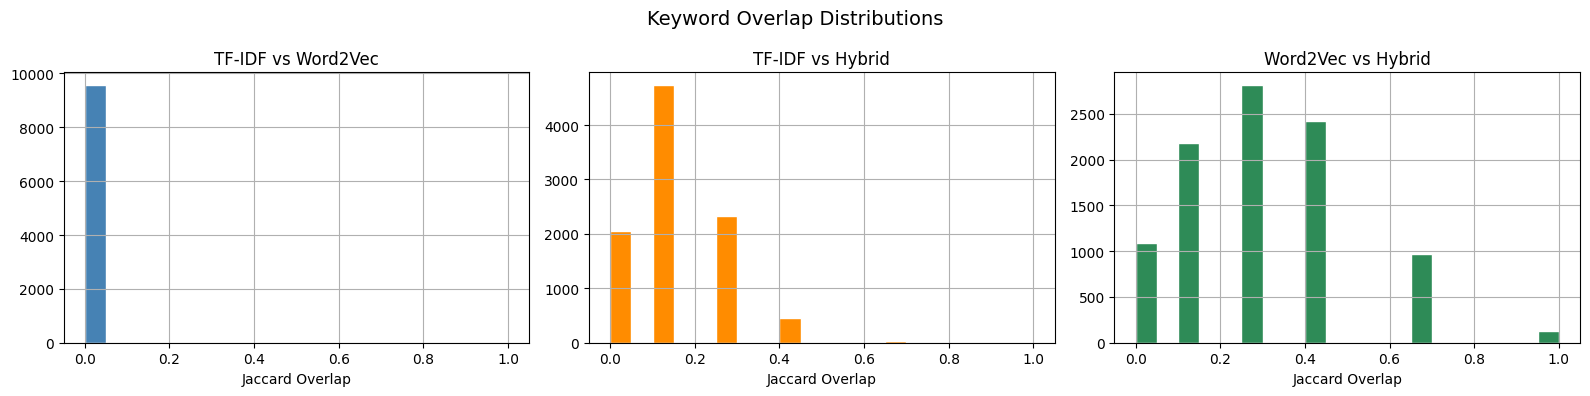

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

papers['overlap_tfidf_w2v'].hist(bins=20,    color='steelblue',  edgecolor='white', ax=axes[0])
axes[0].set_title('TF-IDF vs Word2Vec')
axes[0].set_xlabel('Jaccard Overlap')

papers['overlap_tfidf_hybrid'].hist(bins=20, color='darkorange', edgecolor='white', ax=axes[1])
axes[1].set_title('TF-IDF vs Hybrid')
axes[1].set_xlabel('Jaccard Overlap')

papers['overlap_w2v_hybrid'].hist(bins=20,   color='seagreen',   edgecolor='white', ax=axes[2])
axes[2].set_title('Word2Vec vs Hybrid')
axes[2].set_xlabel('Jaccard Overlap')

plt.suptitle('Keyword Overlap Distributions', fontsize=14)
plt.tight_layout()
plt.show()


### Evaluation Metrics

Since this is an **unsupervised** task, we use proxy metrics:

- **Coverage**: What % of a document's tokens appear as keywords
- **Diversity**: How many unique keywords does each method produce across all papers
- **Keyword Length**: Average characters per keyword 
- **Overlap Rate**: How much methods agree 

In [9]:
import numpy as np

def coverage(tokens, keywords):
    if not tokens:
        return 0.0
    token_set = set(tokens)
    kw_set    = set(keywords)
    return len(token_set & kw_set) / len(token_set)


papers['coverage_tfidf']  = papers.apply(lambda r: coverage(r['lemmatized_tokens'], r['tfidf_keywords']),  axis=1)
papers['coverage_w2v']    = papers.apply(lambda r: coverage(r['lemmatized_tokens'], r['w2v_keywords']),    axis=1)
papers['coverage_hybrid'] = papers.apply(lambda r: coverage(r['lemmatized_tokens'], r['hybrid_keywords']), axis=1)

div_tfidf  = len(set(all_tfidf))
div_w2v    = len(set(all_w2v))
div_hybrid = len(set(all_hybrid))

avg_len_tfidf  = np.mean([len(kw) for kw in all_tfidf])
avg_len_w2v    = np.mean([len(kw) for kw in all_w2v])
avg_len_hybrid = np.mean([len(kw) for kw in all_hybrid])

metrics = pd.DataFrame({
    'Method'          : ['TF-IDF (Baseline)', 'Word2Vec (Advanced)', 'Hybrid (TF-IDF+W2V)'],
    'Avg Coverage'    : [papers['coverage_tfidf'].mean(),  papers['coverage_w2v'].mean(),  papers['coverage_hybrid'].mean()],
    'Unique Keywords' : [div_tfidf,  div_w2v,  div_hybrid],
    'Avg Keyword Len' : [avg_len_tfidf, avg_len_w2v, avg_len_hybrid],
})

metrics = metrics.round(4)
print(metrics.to_string(index=False))

             Method  Avg Coverage  Unique Keywords  Avg Keyword Len
  TF-IDF (Baseline)        0.0066             5344           7.9097
Word2Vec (Advanced)        0.0066            22814          11.9770
Hybrid (TF-IDF+W2V)        0.0066            24932          11.1625


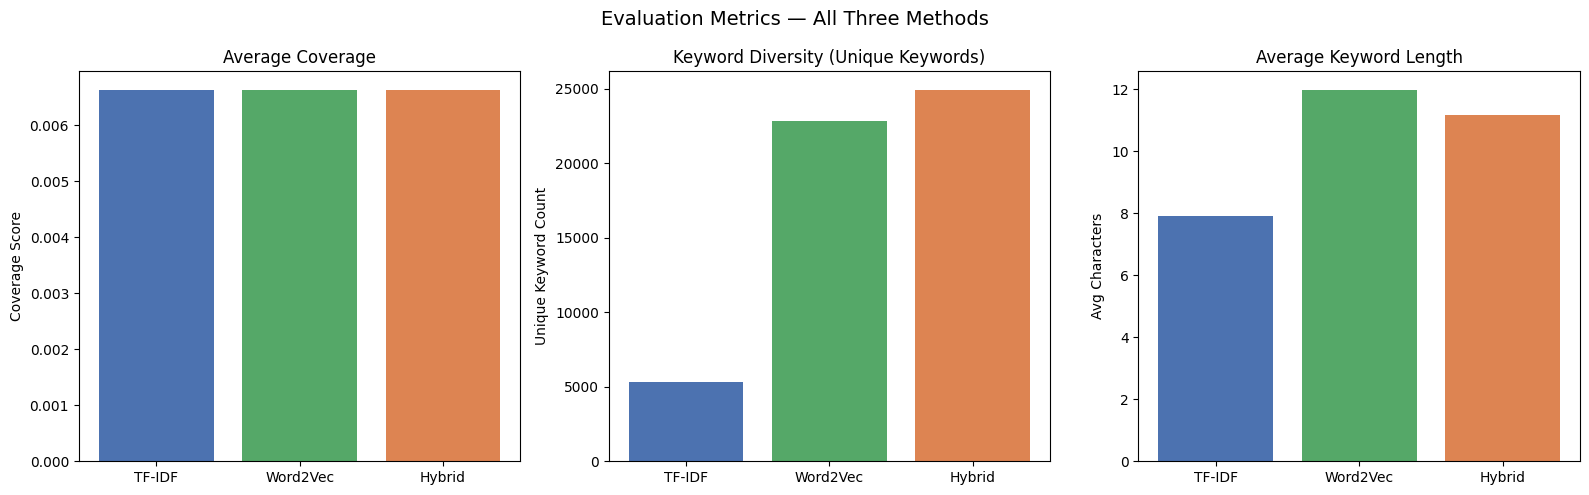

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#4C72B0', '#55A868', '#DD8452']
methods = ['TF-IDF', 'Word2Vec', 'Hybrid']

axes[0].bar(methods,
            [papers['coverage_tfidf'].mean(), papers['coverage_w2v'].mean(), papers['coverage_hybrid'].mean()],
            color=colors)
axes[0].set_title('Average Coverage')
axes[0].set_ylabel('Coverage Score')

axes[1].bar(methods, [div_tfidf, div_w2v, div_hybrid], color=colors)
axes[1].set_title('Keyword Diversity (Unique Keywords)')
axes[1].set_ylabel('Unique Keyword Count')

axes[2].bar(methods, [avg_len_tfidf, avg_len_w2v, avg_len_hybrid], color=colors)
axes[2].set_title('Average Keyword Length')
axes[2].set_ylabel('Avg Characters')

plt.suptitle('Evaluation Metrics — All Three Methods', fontsize=14)
plt.tight_layout()
plt.show()


### Manual Evaluation

We manually inspect 5 papers across different years to qualitatively judge keyword quality.

In [11]:
sample_indices = [0, 50, 200, 500, 1000]

for idx in sample_indices:
    row = papers.iloc[idx]
    title   = row.get('title', f'Paper {idx}')
    preview = ' '.join(str(row.get('full_text', '')).split()[:60])
    
    print(f"{'='*70}")
    print(f"Paper {idx}: {title}")
    print(f"Text preview: {preview}...")
    print(f"  TF-IDF   : {row['tfidf_keywords']}")
    print(f"  Word2Vec : {row['w2v_keywords']}")
    print(f"  Hybrid   : {row['hybrid_keywords']}")
    print()

Paper 0: Bit-Serial Neural Networks
Text preview: bit serial neural networks alan f murray anthony w smith and zoe f butler department of electrical engineering university of edinburgh the kings buildings mayfield road edinburgh scotland eh jl abstract bit serial vlsi neural network is described from an initial architecture for synapse array through to silicon layout and board design the issues surrounding bit serial computation and analogdigital...
  TF-IDF   : ['state', 'synaptic', 'neuron', 'synaptic_weight', 'arithmetic']
  Word2Vec : ['noise_immunity', 'receiv_ing', 'silicon_wafer', 'satura_tion', 'aspire']
  Hybrid   : ['receiv_ing', 'noise_immunity', 'excita_tion', 'satura_tion', 'interconnected_neuron']

Paper 50: Correlational Strength and Computational Algebra of Synaptic Connections Between Neurons
Text preview: correlational strength and computational algebra of synaptic connections between neurons eberhard e fetz department of physiology biophysics university of washington